In [38]:
from tools.audio_utils import read_audio_file
from tools.spectrogram_configs import SpectrogramParams


params = SpectrogramParams(
                nfft=1024,
                hop=1,
                max_dur=0.150,
                songs_per_bird=5,
                overwrite_existing=True,
                use_warping=True)
import pyfftw.interfaces.scipy_fft
import scipy
# Set globally when module is imported
scipy.fft.set_global_backend(pyfftw.interfaces.scipy_fft)

EPSILON = 1e-9  # small constant to avoid log(0)
# Tempo estimation parameters
PEAK_HEIGHT_THRESHOLD = 2e14
LOW_FREQ_THRESHOLD = 3.0
FREQ_RANGE_MIN = 0.125
FREQ_RANGE_MAX = 30.0

In [39]:
audio_file_path = '/Volumes/Extreme SSD/evsong test warp/copied_data/or18or24/or18or24_180823_112402.wav'
audio, fs = read_audio_file(audio_file_path)

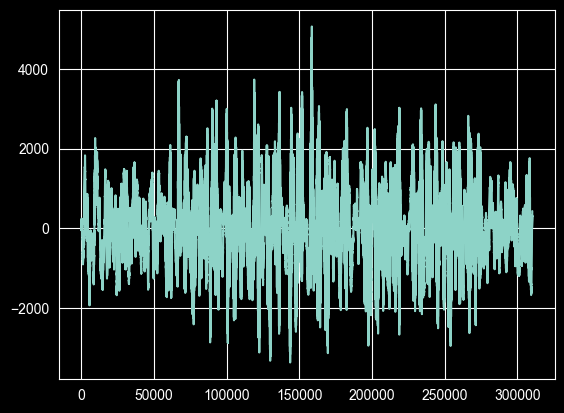

In [40]:
from matplotlib import pyplot as plt
plt.plot(audio)
plt.show()

In [41]:
from tools.signal_utils import smooth, butter_bandpass_filter_sos
import numpy as np

def rms_norm(array):
    """RMS normalization with safe dtype handling"""
    array_f64 = array.astype(np.float64)
    rms = np.sqrt(np.mean(np.square(array_f64)))
    return array_f64 / rms

# Process audio
audio = rms_norm(audio)
audio = butter_bandpass_filter_sos(audio, lowcut=params.min_freq, highcut=params.max_freq, fs=fs, order=3)

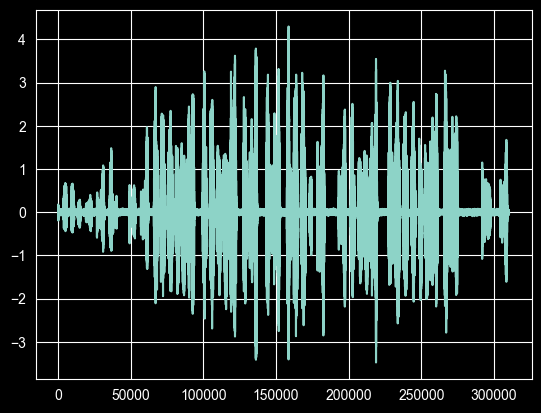

In [42]:
plt.plot(audio)
plt.show()

In [ ]:
audio_norm = audio
rectified_audio = smooth(audio_norm ** 2)

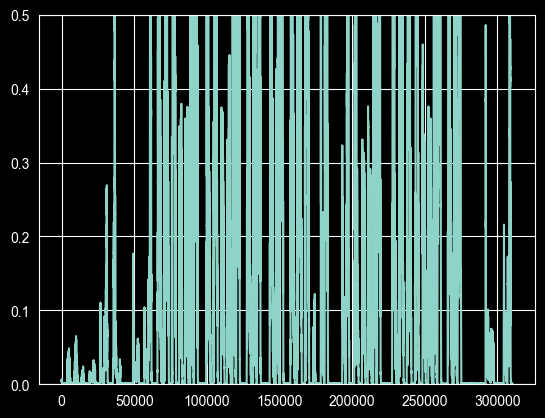

In [56]:
plt.plot(rectified_audio)
plt.ylim(ymin=0, ymax=0.5)
plt.show()

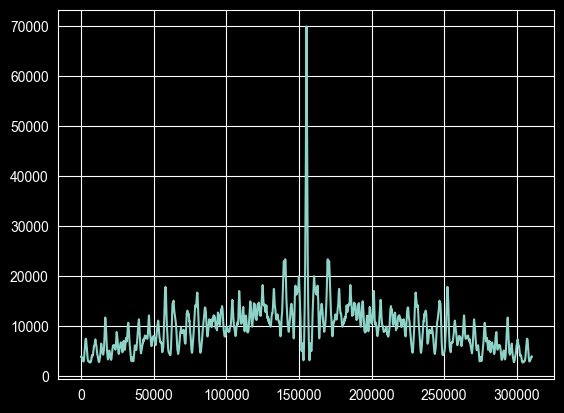

In [43]:
autocorr = np.correlate(rectified_audio, rectified_audio, 'same')

plt.plot(autocorr)
plt.show()

In [44]:
# Compute power spectrum using FFT
power_spectrum = np.abs(np.fft.rfft(autocorr)) ** 2
frequencies = np.fft.rfftfreq(autocorr.size, 1 / fs)

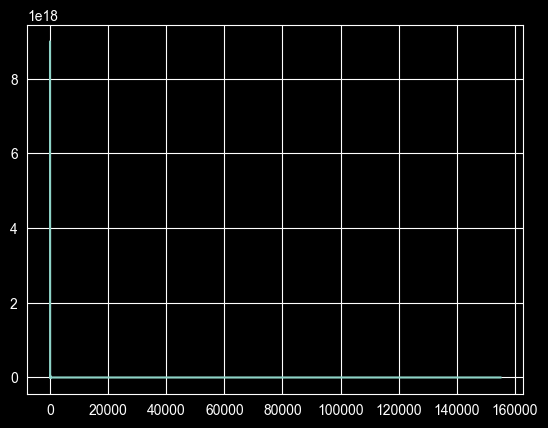

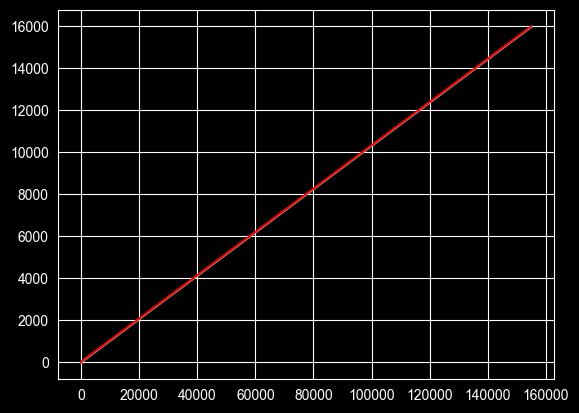

array([False, False,  True, ..., False, False, False], shape=(155201,))

In [45]:
plt.plot(power_spectrum)
plt.show()

plt.plot(frequencies)
plt.plot(frequencies[frequencies > FREQ_RANGE_MAX], color='red')
plt.plot(frequencies[frequencies < FREQ_RANGE_MIN], color='red')
plt.show()
(frequencies >= FREQ_RANGE_MIN) & (frequencies <= FREQ_RANGE_MAX)

In [46]:
len(power_spectrum[(frequencies >= FREQ_RANGE_MIN) & (frequencies <= FREQ_RANGE_MAX)])

290

In [47]:
# Filter to relevant frequency range
freq_mask = (frequencies >= FREQ_RANGE_MIN) & (frequencies <= FREQ_RANGE_MAX)
filtered_power = power_spectrum[freq_mask]
filtered_freqs = frequencies[freq_mask]

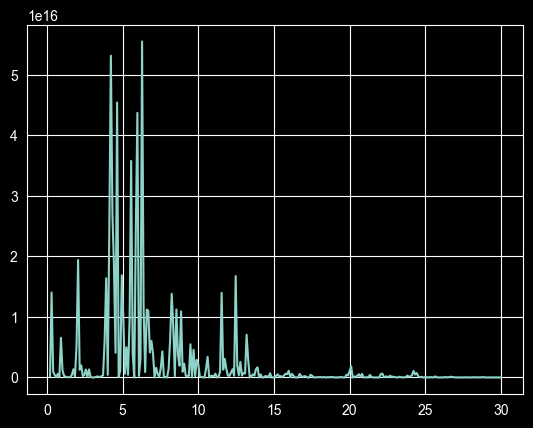

In [48]:
from matplotlib import pyplot as plt
plt.plot(filtered_freqs, filtered_power)
plt.show()

In [49]:
filtered_power[1:50]

array([1.40321377e+16, 9.44260873e+14, 4.11768549e+14, 5.78373099e+13,
       6.06700526e+14, 2.72213996e+13, 6.55163467e+15, 1.16939869e+15,
       2.59363471e+14, 1.32095142e+14, 5.67409391e+13, 3.98822010e+13,
       5.53518280e+13, 4.30474449e+14, 1.36879623e+15, 1.20145332e+14,
       5.32626361e+15, 1.93837818e+16, 1.25650344e+15, 2.00040821e+15,
       2.46115584e+14, 4.05688254e+14, 1.31811140e+15, 8.68297625e+13,
       1.33676181e+15, 9.21552172e+13, 7.12133761e+12, 1.24502764e+12,
       4.21545129e+13, 1.55824514e+14, 1.36109040e+14, 7.18333828e+13,
       2.17608247e+14, 3.60484203e+14, 6.07431806e+15, 1.63889487e+16,
       4.43953787e+14, 2.41920075e+16, 5.31096532e+16, 2.70257418e+16,
       1.81916574e+16, 4.07565366e+15, 4.53968053e+16, 4.97128783e+13,
       1.14682624e+15, 1.68622466e+16, 9.63810013e+15, 6.11124754e+14,
       4.96823808e+15])

In [50]:
PEAK_HEIGHT_THRESHOLD = 1e14  # how to set the peak threshold...?
import scipy.signal as signal
# Find peaks in the power spectrum
peak_indices = signal.find_peaks(filtered_power, height=PEAK_HEIGHT_THRESHOLD)[0]

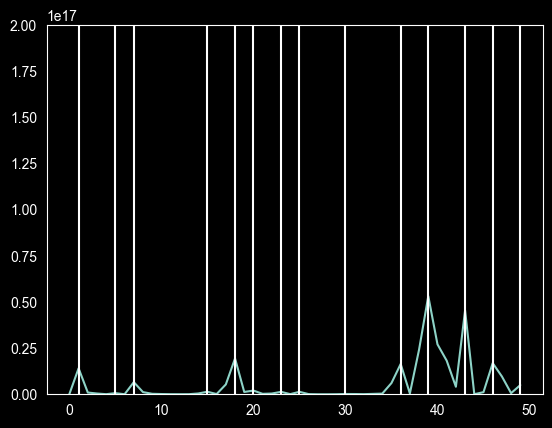

In [51]:
plt.plot(filtered_power[:50])
plt.vlines(peak_indices[peak_indices < 50], ymin=0, ymax=2e17)
plt.ylim(ymin=0, ymax=2e17)
plt.grid(False)
plt.show()

In [52]:
# Calculate peak characteristics
peak_powers = filtered_power[peak_indices]
peak_freqs = filtered_freqs[peak_indices]

# Relative heights for top 3 peaks
relative_heights = peak_powers / np.sum(peak_powers)
top_3_indices = np.argsort(relative_heights)[-3:]

# Low frequency peaks
low_freq_mask = peak_freqs < LOW_FREQ_THRESHOLD
low_freq_peaks = peak_freqs[low_freq_mask] if low_freq_mask.any() else np.array([])

# Calculate tempo estimates
mean_top_3 = np.mean(peak_freqs[top_3_indices]) if len(top_3_indices) > 0 else np.nan
low_freq_mean = np.mean(low_freq_peaks) if len(low_freq_peaks) > 0 else np.nan
mean_all = np.mean(peak_freqs)

In [53]:
mean_all

np.float64(12.538473031525475)

In [54]:
mean_top_3

np.float64(5.051546391752577)

In [ ]:
from tools.warping import align_specs, apply_warp
